# Instacart EDA

This notebook performs a simple exploratory data analysis (EDA) of the Instacart dataset.

## Goals
- Load and inspect all main tables
- Check missing values and duplicates
- Analyze orders by day and hour
- Explore products, aisles, and departments
- Identify common and rare products
- Build a first view of customer purchase behavior


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
def load_instacart_tables():
    """
    Load the main Instacart tables.
    """
    tables = {
        "orders": pd.read_csv("../data/orders.csv"),
        "order_products__prior": pd.read_csv("../data/order_products__prior.csv"),
        "order_products__train": pd.read_csv("../data/order_products__train.csv"),
        "products": pd.read_csv("../data/products.csv"),
        "aisles": pd.read_csv("../data/aisles.csv"),
        "departments": pd.read_csv("../data/departments.csv"),
    }
    return tables


def table_overview(df, name):
    """
    Return a simple table summary.
    """
    out = pd.DataFrame([{
        "table": name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    }])
    return out


def missing_report(df, name):
    """
    Return missing values by column.
    """
    out = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
    })
    out["missing_pct"] = (out["missing_count"] / len(df)) * 100
    out["table"] = name
    out = out.sort_values("missing_count", ascending=False).reset_index(drop=True)
    return out


def implicit_missing_orders(orders):
    """
    Check implicit missingness in orders.
    """
    out = pd.DataFrame([{
        "days_since_prior_order_missing": int(orders["days_since_prior_order"].isna().sum()),
        "eval_set_missing": int(orders["eval_set"].astype(str).str.strip().eq("").sum()),
        "order_dow_out_of_range": int((~orders["order_dow"].between(0, 6)).sum()),
        "order_hour_out_of_range": int((~orders["order_hour_of_day"].between(0, 23)).sum()),
    }])
    return out


def enrich_products(products, aisles, departments):
    """
    Merge products with aisle and department names.
    """
    df = products.merge(aisles, on="aisle_id", how="left")
    df = df.merge(departments, on="department_id", how="left")
    return df


def plot_orders_by_day(orders):
    """
    Plot orders by day of week.
    """
    counts = orders["order_dow"].value_counts().sort_index()
    plt.figure(figsize=(7, 4))
    sns.barplot(x=counts.index, y=counts.values)
    plt.title("Orders by day of week")
    plt.xlabel("order_dow")
    plt.ylabel("number of orders")
    plt.show()


def plot_orders_by_hour(orders):
    """
    Plot orders by hour of day.
    """
    counts = orders["order_hour_of_day"].value_counts().sort_index()
    plt.figure(figsize=(8, 4))
    sns.lineplot(x=counts.index, y=counts.values, marker="o")
    plt.title("Orders by hour of day")
    plt.xlabel("order_hour_of_day")
    plt.ylabel("number of orders")
    plt.show()


def product_frequency(order_products_prior, products_enriched):
    """
    Count product occurrences in prior orders.
    """
    freq = order_products_prior.groupby("product_id").size().reset_index(name="n_purchases")
    freq = freq.merge(
        products_enriched[["product_id", "product_name", "aisle", "department"]],
        on="product_id",
        how="left",
    )
    freq = freq.sort_values("n_purchases", ascending=False).reset_index(drop=True)
    return freq


def department_distribution(order_products_prior, products_enriched):
    """
    Compute department distribution in prior orders.
    """
    tmp = order_products_prior.merge(
        products_enriched[["product_id", "department"]],
        on="product_id",
        how="left",
    )
    out = tmp.groupby("department").size().reset_index(name="n_lines")
    out["share"] = out["n_lines"] / out["n_lines"].sum()
    out = out.sort_values("n_lines", ascending=False).reset_index(drop=True)
    return out


def aisle_distribution(order_products_prior, products_enriched, top_n=20):
    """
    Compute top aisle distribution in prior orders.
    """
    tmp = order_products_prior.merge(
        products_enriched[["product_id", "aisle"]],
        on="product_id",
        how="left",
    )
    out = tmp.groupby("aisle").size().reset_index(name="n_lines")
    out["share"] = out["n_lines"] / out["n_lines"].sum()
    out = out.sort_values("n_lines", ascending=False).reset_index(drop=True)
    return out.head(top_n)


def build_customer_features(orders, order_products_prior):
    """
    Build simple customer features from prior history.
    """
    # Keep only prior orders
    prior_orders = orders[orders["eval_set"] == "prior"][["order_id", "user_id", "order_number"]].copy()

    # Basket size per prior order
    basket_sizes = order_products_prior.groupby("order_id").size().reset_index(name="basket_size")
    basket_sizes = basket_sizes.merge(prior_orders, on="order_id", how="left")

    # Customer features
    user_orders = prior_orders.groupby("user_id")["order_id"].nunique().reset_index(name="n_prior_orders")

    user_items = basket_sizes.groupby("user_id").agg(
        total_items_prior=("basket_size", "sum"),
        avg_basket_size_prior=("basket_size", "mean"),
        basket_size_std=("basket_size", "std"),
    ).reset_index()

    rr = order_products_prior.merge(prior_orders[["order_id", "user_id"]], on="order_id", how="left")
    user_reorder = rr.groupby("user_id")["reordered"].mean().reset_index(name="reorder_rate")

    features = user_orders.merge(user_items, on="user_id", how="left")
    features = features.merge(user_reorder, on="user_id", how="left")
    return features


def first_last_products(orders, order_products_prior, products_enriched, top_n=10):
    """
    Compare products in first vs last prior order.
    """
    prior_orders = orders[orders["eval_set"] == "prior"][["order_id", "user_id", "order_number"]].copy()

    first_orders = prior_orders.sort_values("order_number").groupby("user_id").head(1)
    last_orders = prior_orders.sort_values("order_number").groupby("user_id").tail(1)

    first_ids = set(first_orders["order_id"])
    last_ids = set(last_orders["order_id"])

    first_op = order_products_prior[order_products_prior["order_id"].isin(first_ids)].copy()
    last_op = order_products_prior[order_products_prior["order_id"].isin(last_ids)].copy()

    first_freq = product_frequency(first_op, products_enriched).head(top_n)
    last_freq = product_frequency(last_op, products_enriched).head(top_n)

    return first_freq, last_freq

In [ ]:
# Load data
tables = load_instacart_tables()

orders = tables["orders"]
op_prior = tables["order_products__prior"]
op_train = tables["order_products__train"]
products = tables["products"]
aisles = tables["aisles"]
departments = tables["departments"]

In [ ]:
# Basic overview of all tables
overview_list = [
    table_overview(orders, "orders"),
    table_overview(op_prior, "order_products__prior"),
    table_overview(op_train, "order_products__train"),
    table_overview(products, "products"),
    table_overview(aisles, "aisles"),
    table_overview(departments, "departments"),
]

overview_df = pd.concat(overview_list, ignore_index=True)
display(overview_df)

,table,rows,cols,missing_cells,duplicate_rows
0,orders,3421083,7,206209,0
1,order_products__prior,32434489,4,0,0
2,order_products__train,1384617,4,0,0
3,products,49688,4,0,0
4,aisles,134,2,0,0
5,departments,21,2,0,0


In [7]:
# Show first rows
display(orders.head())
display(op_prior.head())
display(op_train.head())
display(products.head())
display(aisles.head())
display(departments.head())

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [ ]:
# Missing values (explicit + implicit)
display(missing_report(orders, "orders"))
display(missing_report(op_prior, "order_products__prior"))
display(missing_report(op_train, "order_products__train"))
display(missing_report(products, "products"))
display(missing_report(aisles, "aisles"))
display(missing_report(departments, "departments"))

display(implicit_missing_orders(orders))

,column,missing_count,missing_pct,table
0,days_since_prior_order,206209,6.027594,orders
1,user_id,0,0.000000,orders
2,order_id,0,0.000000,orders
3,eval_set,0,0.000000,orders
4,order_number,0,0.000000,orders
5,order_dow,0,0.000000,orders
6,order_hour_of_day,0,0.000000,orders


,column,missing_count,missing_pct,table
0,order_id,0,0.0,order_products__prior
1,product_id,0,0.0,order_products__prior
2,add_to_cart_order,0,0.0,order_products__prior
3,reordered,0,0.0,order_products__prior


,column,missing_count,missing_pct,table
0,order_id,0,0.0,order_products__train
1,product_id,0,0.0,order_products__train
2,add_to_cart_order,0,0.0,order_products__train
3,reordered,0,0.0,order_products__train


,column,missing_count,missing_pct,table
0,product_id,0,0.0,products
1,product_name,0,0.0,products
2,aisle_id,0,0.0,products
3,department_id,0,0.0,products


,column,missing_count,missing_pct,table
0,aisle_id,0,0.0,aisles
1,aisle,0,0.0,aisles


,column,missing_count,missing_pct,table
0,department_id,0,0.0,departments
1,department,0,0.0,departments


,days_since_prior_order_missing,eval_set_missing,order_dow_out_of_range,order_hour_out_of_range
0,206209,0,0,0


In [ ]:
# Product table enrichment
products_enriched = enrich_products(products, aisles, departments)
display(products_enriched.head())

,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


In [10]:
# Check department and aisle coverage
dep_counts = products_enriched["department"].value_counts(dropna=False).reset_index()
dep_counts.columns = ["department", "n_products"]
display(dep_counts)

aisle_counts = products_enriched["aisle"].value_counts(dropna=False).reset_index()
aisle_counts.columns = ["aisle", "n_products"]
display(aisle_counts.head(20))

,department,n_products
0,personal care,6563
1,snacks,6264
2,pantry,5371
3,beverages,4365
4,frozen,4007
5,dairy eggs,3449
6,household,3085
7,canned goods,2092
8,dry goods pasta,1858
9,produce,1684


,aisle,n_products
0,missing,1258
1,candy chocolate,1246
2,ice cream ice,1091
3,vitamins supplements,1038
4,yogurt,1026
5,chips pretzels,989
6,tea,894
7,packaged cheese,891
8,frozen meals,880
9,cookies cakes,874


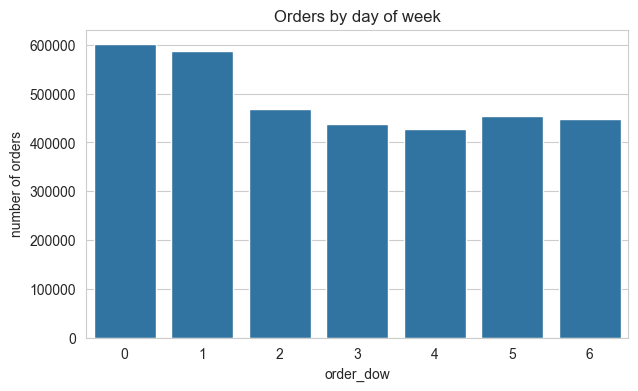

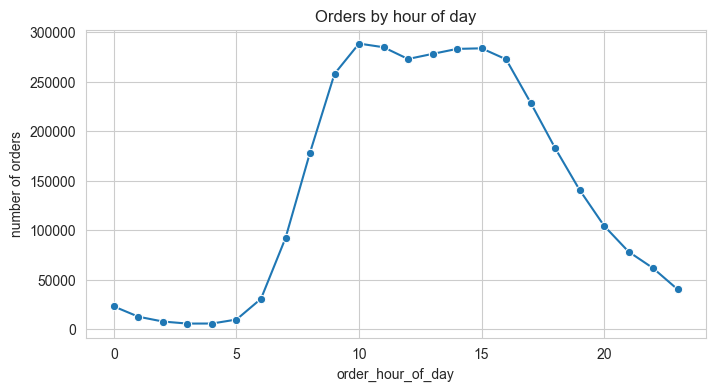

In [ ]:
# Orders analysis
plot_orders_by_day(orders)
plot_orders_by_hour(orders)

In [12]:
# Eval set distribution
eval_counts = orders["eval_set"].value_counts().reset_index()
eval_counts.columns = ["eval_set", "n_orders"]
display(eval_counts)

,eval_set,n_orders
0,prior,3214874
1,train,131209
2,test,75000


In [ ]:
# Product popularity (prior)
prod_freq = product_frequency(op_prior, products_enriched)

display(prod_freq.head(20))      # Most purchased
display(prod_freq.tail(20))      # Rare products

,product_id,n_purchases,product_name,aisle,department
0,24852,472565,Banana,fresh fruits,produce
1,13176,379450,Bag of Organic Bananas,fresh fruits,produce
2,21137,264683,Organic Strawberries,fresh fruits,produce
3,21903,241921,Organic Baby Spinach,packaged vegetables fruits,produce
4,47209,213584,Organic Hass Avocado,fresh fruits,produce
5,47766,176815,Organic Avocado,fresh fruits,produce
6,47626,152657,Large Lemon,fresh fruits,produce
7,16797,142951,Strawberries,fresh fruits,produce
8,26209,140627,Limes,fresh fruits,produce
9,27845,137905,Organic Whole Milk,milk,dairy eggs


,product_id,n_purchases,product_name,aisle,department
49657,44748,1,Thick 'n Chunky Salsa Mild,condiments,pantry
49658,46278,1,Berry Sprouted Blend Cereal,cereal,breakfast
49659,43098,1,Buddy Bear Probiotic Orange Flavor Chewable,digestion,personal care
49660,30343,1,Seltzer Blueberry Lemonade,missing,missing
49661,9818,1,Cld/Flu Van Chrry,cold flu allergy,personal care
49662,28818,1,Hot Oatmeal Multigrain Raisin,hot cereal pancake mixes,breakfast
49663,7712,1,String Of Pearl White Sprinkles,baking supplies decor,pantry
49664,4417,1,Organic Veggie Ground,tofu meat alternatives,deli
49665,47408,1,Control GX Gray Reducing Shampoo,missing,missing
49666,14485,1,Organic Ice Cream Birthday Cake,ice cream ice,frozen


In [14]:
# check of rare product ratio
rare_threshold = 5
n_rare = int((prod_freq["n_purchases"] <= rare_threshold).sum())
n_total_products_seen = len(prod_freq)
rare_ratio = n_rare / n_total_products_seen if n_total_products_seen > 0 else 0

rare_summary = pd.DataFrame([{
    "rare_threshold_purchases": rare_threshold,
    "n_rare_products": n_rare,
    "n_products_seen_in_prior": n_total_products_seen,
    "rare_ratio": rare_ratio,
}])
display(rare_summary)

,rare_threshold_purchases,n_rare_products,n_products_seen_in_prior,rare_ratio
0,5,3171,49677,0.063832


,department,n_lines,share
0,produce,9479291,0.292260
1,dairy eggs,5414016,0.166922
2,snacks,2887550,0.089027
3,beverages,2690129,0.082940
4,frozen,2236432,0.068952
5,pantry,1875577,0.057827
6,bakery,1176787,0.036282
7,canned goods,1068058,0.032930
8,deli,1051249,0.032411
9,dry goods pasta,866627,0.026719


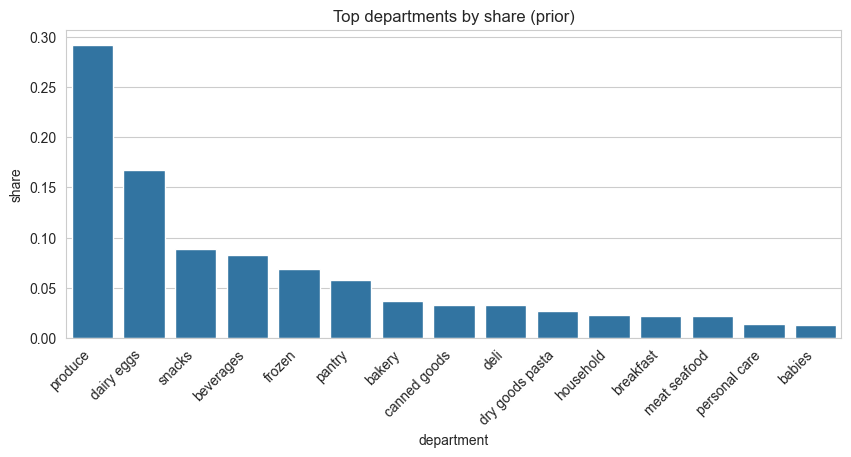

,aisle,n_lines,share
0,fresh fruits,3642188,0.112294
1,fresh vegetables,3418021,0.105382
2,packaged vegetables fruits,1765313,0.054427
3,yogurt,1452343,0.044778
4,packaged cheese,979763,0.030207
5,milk,891015,0.027471
6,water seltzer sparkling water,841533,0.025946
7,chips pretzels,722470,0.022275
8,soy lactosefree,638253,0.019678
9,bread,584834,0.018031


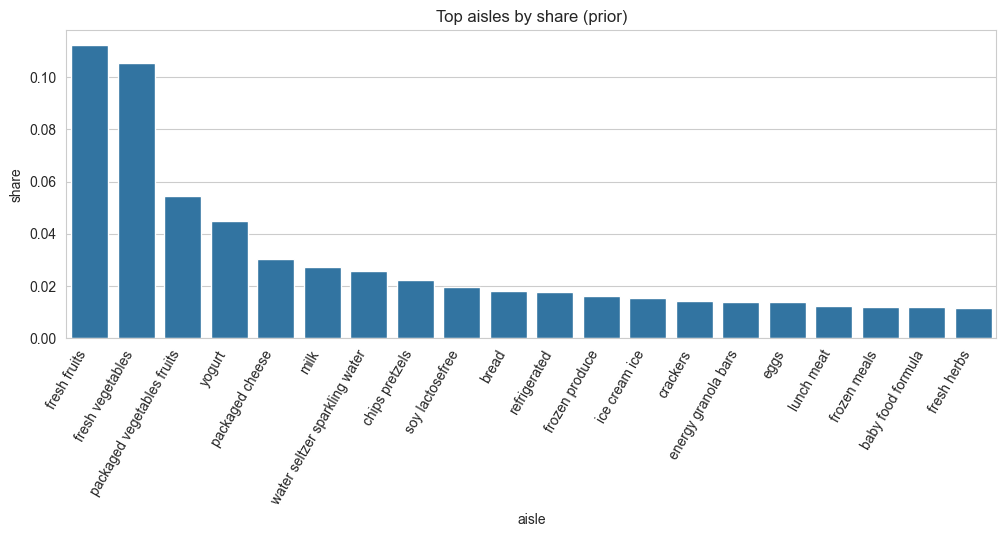

In [ ]:
# Department and aisle usage in prior orders
dep_dist = department_distribution(op_prior, products_enriched)
display(dep_dist)

plt.figure(figsize=(10, 4))
sns.barplot(data=dep_dist.head(15), x="department", y="share")
plt.title("Top departments by share (prior)")
plt.xlabel("department")
plt.ylabel("share")
plt.xticks(rotation=45, ha="right")
plt.show()

aisle_dist = aisle_distribution(op_prior, products_enriched, top_n=20)
display(aisle_dist)

plt.figure(figsize=(12, 4))
sns.barplot(data=aisle_dist, x="aisle", y="share")
plt.title("Top aisles by share (prior)")
plt.xlabel("aisle")
plt.ylabel("share")
plt.xticks(rotation=60, ha="right")
plt.show()

In [ ]:
# Customer behavior (simple features)
user_features = build_customer_features(orders, op_prior)
display(user_features.head())

,user_id,n_prior_orders,total_items_prior,avg_basket_size_prior,basket_size_std,reorder_rate
0,1,10,59,5.900000,1.523884,0.694915
1,2,14,195,13.928571,5.717238,0.476923
2,3,12,88,7.333333,2.103388,0.625000
3,4,5,18,3.600000,2.073644,0.055556
4,5,4,37,9.250000,3.095696,0.378378


In [17]:
# Heavy customers (top by total items)
heavy_customers = user_features.sort_values("total_items_prior", ascending=False).head(20)
display(heavy_customers)

,user_id,n_prior_orders,total_items_prior,avg_basket_size_prior,basket_size_std,reorder_rate
201267,201268,99,3725,37.626263,26.461596,0.879195
129927,129928,64,3638,56.843750,32.094216,0.870533
164054,164055,99,3061,30.919192,9.795539,0.868017
186703,186704,99,2936,29.656566,16.849975,0.869550
176477,176478,99,2921,29.505051,19.786294,0.831565
182400,182401,99,2907,29.363636,12.301032,0.750258
137628,137629,99,2901,29.303030,11.806652,0.902792
33730,33731,99,2888,29.171717,18.250547,0.829986
108186,108187,59,2760,46.779661,18.109883,0.886232
4693,4694,89,2735,30.730337,14.907872,0.803656


In [18]:
# Summary statistics
user_summary = user_features[[
    "n_prior_orders",
    "total_items_prior",
    "avg_basket_size_prior",
    "basket_size_std",
    "reorder_rate",
]].describe().T
display(user_summary)

,count,mean,std,min,25%,50%,75%,max
n_prior_orders,206209.0,15.590367,16.654774,3.0,5.000000,9.000000,19.000000,99.000000
total_items_prior,206209.0,157.289396,204.208233,3.0,39.000000,83.000000,188.000000,3725.000000
avg_basket_size_prior,206209.0,9.951586,5.863570,1.0,5.740741,8.933333,13.000000,70.250000
basket_size_std,206209.0,4.266349,2.675061,0.0,2.345208,3.781534,5.609516,44.747439
reorder_rate,206209.0,0.432249,0.212144,0.0,0.267857,0.428571,0.595745,0.989529


In [ ]:
# First vs last prior order products
first_top, last_top = first_last_products(orders, op_prior, products_enriched, top_n=15)

print("Top products in first prior orders")
display(first_top[["product_id", "product_name", "department", "aisle", "n_purchases"]])

print("Top products in last prior orders")
display(last_top[["product_id", "product_name", "department", "aisle", "n_purchases"]])

Top products in first prior orders


,product_id,product_name,department,aisle,n_purchases
0,24852,Banana,produce,fresh fruits,29534
1,13176,Bag of Organic Bananas,produce,fresh fruits,19158
2,21137,Organic Strawberries,produce,fresh fruits,16464
3,47766,Organic Avocado,produce,fresh fruits,15187
4,21903,Organic Baby Spinach,produce,packaged vegetables fruits,14948
5,47209,Organic Hass Avocado,produce,fresh fruits,11106
6,16797,Strawberries,produce,fresh fruits,8660
7,26209,Limes,produce,fresh fruits,8598
8,47626,Large Lemon,produce,fresh fruits,8360
9,27845,Organic Whole Milk,dairy eggs,milk,7223


Top products in last prior orders


,product_id,product_name,department,aisle,n_purchases
0,24852,Banana,produce,fresh fruits,29414
1,13176,Bag of Organic Bananas,produce,fresh fruits,24093
2,21137,Organic Strawberries,produce,fresh fruits,15590
3,21903,Organic Baby Spinach,produce,packaged vegetables fruits,15410
4,47626,Large Lemon,produce,fresh fruits,12100
5,47209,Organic Hass Avocado,produce,fresh fruits,11561
6,47766,Organic Avocado,produce,fresh fruits,11545
7,16797,Strawberries,produce,fresh fruits,10012
8,26209,Limes,produce,fresh fruits,9187
9,27966,Organic Raspberries,produce,packaged vegetables fruits,8591
